In [2]:
import sys
from os.path import exists

# this is the repository I pulled/downloaded from github: 
CONGA_PATH = r"C:\Users\andre\conga"
# confirm that it's the right level directory (since the repo and library have the same name)
assert exists(CONGA_PATH+'/README.md')
sys.path.append(CONGA_PATH)
import scanpy as sc
import conga
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r"C:\Users\andre\revision")

In [3]:
clones_file = 'gut_liver_TRM_clones_without0.tsv'
organism = 'human'
outfile_prefix = 'conga_output_gut_liver_TRM' 

In [4]:
# Nice palette generated by @xuancong84 and @Greg0ry on stack overflow
import math
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.cm import hsv


def generate_colormap(number_of_distinct_colors: int = 80):
    if number_of_distinct_colors == 0:
        number_of_distinct_colors = 80

    number_of_shades = 7
    number_of_distinct_colors_with_multiply_of_shades = int(math.ceil(number_of_distinct_colors / number_of_shades) * number_of_shades)

    # Create an array with uniformly drawn floats taken from <0, 1) partition
    linearly_distributed_nums = np.arange(number_of_distinct_colors_with_multiply_of_shades) / number_of_distinct_colors_with_multiply_of_shades

    # We are going to reorganise monotonically growing numbers in such way that there will be single array with saw-like pattern
    #     but each saw tooth is slightly higher than the one before
    # First divide linearly_distributed_nums into number_of_shades sub-arrays containing linearly distributed numbers
    arr_by_shade_rows = linearly_distributed_nums.reshape(number_of_shades, number_of_distinct_colors_with_multiply_of_shades // number_of_shades)

    # Transpose the above matrix (columns become rows) - as a result each row contains saw tooth with values slightly higher than row above
    arr_by_shade_columns = arr_by_shade_rows.T

    # Keep number of saw teeth for later
    number_of_partitions = arr_by_shade_columns.shape[0]

    # Flatten the above matrix - join each row into single array
    nums_distributed_like_rising_saw = arr_by_shade_columns.reshape(-1)

    # HSV colour map is cyclic (https://matplotlib.org/tutorials/colors/colormaps.html#cyclic), we'll use this property
    initial_cm = hsv(nums_distributed_like_rising_saw)

    lower_partitions_half = number_of_partitions // 2
    upper_partitions_half = number_of_partitions - lower_partitions_half

    # Modify lower half in such way that colours towards beginning of partition are darker
    # First colours are affected more, colours closer to the middle are affected less
    lower_half = lower_partitions_half * number_of_shades
    for i in range(3):
        initial_cm[0:lower_half, i] *= np.arange(0.2, 1, 0.8/lower_half)

    # Modify second half in such way that colours towards end of partition are less intense and brighter
    # Colours closer to the middle are affected less, colours closer to the end are affected more
    for i in range(3):
        for j in range(upper_partitions_half):
            modifier = np.ones(number_of_shades) - initial_cm[lower_half + j * number_of_shades: lower_half + (j + 1) * number_of_shades, i]
            modifier = j * modifier / upper_partitions_half
            initial_cm[lower_half + j * number_of_shades: lower_half + (j + 1) * number_of_shades, i] += modifier

    return ListedColormap(initial_cm)

(35, 4)


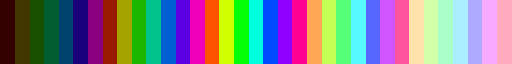

In [50]:
cmap_30=generate_colormap(5*6)
print(cmap_30.colors.shape)
cmap_30

In [6]:
adata_ab = sc.read_h5ad('250721_gut_liver_TRM_adata_abTCR_conga.h5ad')

In [40]:
adata = sc.read_h5ad(r"D:\Trapecar\250307_gut_liver_blood_ultimate_annotated.h5ad")

prepare data to meet conga's standard

In [41]:
adata.obs.columns

Index(['has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a',
       'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes',
       'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff',
       'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type',
       'activation', 'tissue', 'general subtype', 'celltype',
       'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation',
       'major celltype', 'major general subtype', 'Donor ID',
       'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation',
       'cluster+celltype w/ activation',
       'tissue+cluster+celltype w/ activation', 'act_score',
       'donor+tissue+celltype w/ activation'],
      dtype='object')

In [42]:
adata.obs['va'] = adata.obs['TRAV']
adata.obs['ja'] = adata.obs['TRAJ'] 
adata.obs['vb'] = adata.obs['TRBV'] 
adata.obs['jb'] = adata.obs['TRBJ'] 

In [43]:
adata_TCR = adata[adata.obs['chain_pairing'].isin(["single pair", "extra VJ","extra VDJ","two full chains"]),:]

In [44]:
adata_ab = adata_TCR[adata_TCR.obs['general type'].isin(['TCRab CD4','TCRab CD8aa','TCRab CD8ab']),:]

In [45]:
adata_ab.obs['clone_code'] = adata_ab.obs['TRAV'].astype(str).map(str)+' '+adata_ab.obs['TRBV'].astype(str).map(str)+' '+adata_ab.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab.obs['cdr3b'].astype(str).map(str)

C:\Users\andre\AppData\Local\Temp\ipykernel_28572\3965735778.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ab.obs['clone_code'] = adata_ab.obs['TRAV'].astype(str).map(str)+' '+adata_ab.obs['TRBV'].astype(str).map(str)+' '+adata_ab.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab.obs['cdr3b'].astype(str).map(str)


check the public clone just our of curiosity

In [15]:
clone_df = adata_ab.obs[[ 'batch','TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3a', 'cdr3b','clone_code']]

In [86]:
clone_counts = clone_df.groupby(['batch','clone_code']).size().reset_index(name='clone_size')
clone_counts[['TRAV','TRBV','cdr3a','cdr3b']] = clone_counts['clone_code'].str.split(' ', expand=True)

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\2577822773.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_counts = clone_df.groupby(['batch','clone_code']).size().reset_index(name='clone_size')


In [82]:
clone_df.groupby(['batch', 'clone_code'])['TRAJ'].apply(lambda x: len(set(x))).sort_values(ascending=False)
#Just to confirm Js are unique to our clonotype strategy

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\2966889109.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_df.groupby(['batch', 'clone_code'])['TRAJ'].apply(lambda x: len(set(x))).sort_values(ascending=False)


batch  clone_code                                      
5      TRAV9-2 TRBV9 CALSPYGGATNKLIF CASSVGTGGPNEQFF       1.0
3      TRAV1-1 TRBV10-2 CAGDNYGQNFVF CASRAGGVTEAFF         1.0
       TRAV1-1 TRBV10-2 CAVRDQLPAGKSTF CASRGGGGNNEQFF      1.0
       TRAV1-1 TRBV10-3 CAGGGSAAGNKLTF CAISERPGTENEKLFF    1.0
       TRAV1-1 TRBV10-3 CAGMDSNYQLIW CAISDDRGHRNYGYTF      1.0
                                                          ... 
5      TRAV9-2 TRBV9 CALSPYNFNKFYF CASSVEVVPHEQYF          NaN
       TRAV9-2 TRBV9 CALSSNQAGTALIF CASSMDRGHNEQFF         NaN
       TRAV9-2 TRBV9 CALSTLDSSYKLIF CASSVEGSGGPNIQYF       NaN
       TRAV9-2 TRBV9 CALYTGGFKTIF CASSVSGLAGGSYNEQFF       NaN
       TRAV9-2 TRBV9 CASETSGSRLTF CASSVGRTANIQYF           NaN
Name: TRAJ, Length: 56421, dtype: float64

In [93]:
Jmap = clone_df[['TRAJ','TRBJ','clone_code']].drop_duplicates()
Jmap = Jmap.set_index('clone_code')
Jmap_adict = Jmap['TRAJ'].to_dict()
Jmap_bdict = Jmap['TRBJ'].to_dict()

In [94]:
clone_counts['ja_gene'] =clone_counts['clone_code'].replace(Jmap_adict)
clone_counts['jb_gene'] =clone_counts['clone_code'].replace(Jmap_bdict)

In [95]:
clone_counts

,batch,clone_code,clone_size,TRAV,TRBV,cdr3a,cdr3b,ja_gene,jb_gene
0,3,TRAV1-1 TRBV10-2 CAGDNYGQNFVF CASRAGGVTEAFF,1,TRAV1-1,TRBV10-2,CAGDNYGQNFVF,CASRAGGVTEAFF,TRAJ26,TRBJ1-1
1,3,TRAV1-1 TRBV10-2 CAVRDQLPAGKSTF CASRGGGGNNEQFF,1,TRAV1-1,TRBV10-2,CAVRDQLPAGKSTF,CASRGGGGNNEQFF,TRAJ27,TRBJ2-1
2,3,TRAV1-1 TRBV10-2 CAVREGSSNTGKLIF CASSDPSGAKEETQYF,0,TRAV1-1,TRBV10-2,CAVREGSSNTGKLIF,CASSDPSGAKEETQYF,TRAJ37,TRBJ2-5
3,3,TRAV1-1 TRBV10-3 CAGGGSAAGNKLTF CAISERPGTENEKLFF,1,TRAV1-1,TRBV10-3,CAGGGSAAGNKLTF,CAISERPGTENEKLFF,TRAJ17,TRBJ1-4
4,3,TRAV1-1 TRBV10-3 CAGMDSNYQLIW CAISDDRGHRNYGYTF,1,TRAV1-1,TRBV10-3,CAGMDSNYQLIW,CAISDDRGHRNYGYTF,TRAJ33,TRBJ1-2
...,...,...,...,...,...,...,...,...,...
56416,5,TRAV9-2 TRBV9 CALSPYNFNKFYF CASSVEVVPHEQYF,0,TRAV9-2,TRBV9,CALSPYNFNKFYF,CASSVEVVPHEQYF,TRAJ21,TRBJ2-7
56417,5,TRAV9-2 TRBV9 CALSSNQAGTALIF CASSMDRGHNEQFF,0,TRAV9-2,TRBV9,CALSSNQAGTALIF,CASSMDRGHNEQFF,TRAJ15,TRBJ2-1
56418,5,TRAV9-2 TRBV9 CALSTLDSSYKLIF CASSVEGSGGPNIQYF,0,TRAV9-2,TRBV9,CALSTLDSSYKLIF,CASSVEGSGGPNIQYF,TRAJ12,TRBJ2-4
56419,5,TRAV9-2 TRBV9 CALYTGGFKTIF CASSVSGLAGGSYNEQFF,0,TRAV9-2,TRBV9,CALYTGGFKTIF,CASSVSGLAGGSYNEQFF,TRAJ9,TRBJ2-1


In [51]:
clone_replace_dict = clone_counts['clone_code'].drop_duplicates().reset_index().set_index('clone_code')['index'].to_dict()

In [96]:
clone_counts['clone_code'] = clone_counts['clone_code'].replace(clone_replace_dict)

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\3147651609.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clone_counts['clone_code'] = clone_counts['clone_code'].replace(clone_replace_dict)


In [ ]:
clone_counts['clone_code'] = 'clonotype'+clone_counts['clone_code'].astype(str).map(str)

In [103]:
clone_counts = clone_counts.rename(columns = {'batch':'subject',
                                              'clone_code':'clone_id',
                                              'TRAV':'va_gene',
                                              'TRBV':'vb_gene',
                                              'TRAJ':'ja_gene',
                                              'TRBJ':'jb_gene'})

In [108]:
clone_counts

,subject,clone_id,clone_size,va_gene,vb_gene,cdr3a,cdr3b,ja_gene,jb_gene
0,3,clonotype0,1,TRAV1-1,TRBV10-2,CAGDNYGQNFVF,CASRAGGVTEAFF,TRAJ26,TRBJ1-1
1,3,clonotype1,1,TRAV1-1,TRBV10-2,CAVRDQLPAGKSTF,CASRGGGGNNEQFF,TRAJ27,TRBJ2-1
2,3,clonotype2,0,TRAV1-1,TRBV10-2,CAVREGSSNTGKLIF,CASSDPSGAKEETQYF,TRAJ37,TRBJ2-5
3,3,clonotype3,1,TRAV1-1,TRBV10-3,CAGGGSAAGNKLTF,CAISERPGTENEKLFF,TRAJ17,TRBJ1-4
4,3,clonotype4,1,TRAV1-1,TRBV10-3,CAGMDSNYQLIW,CAISDDRGHRNYGYTF,TRAJ33,TRBJ1-2
...,...,...,...,...,...,...,...,...,...
56416,5,clonotype18802,0,TRAV9-2,TRBV9,CALSPYNFNKFYF,CASSVEVVPHEQYF,TRAJ21,TRBJ2-7
56417,5,clonotype18803,0,TRAV9-2,TRBV9,CALSSNQAGTALIF,CASSMDRGHNEQFF,TRAJ15,TRBJ2-1
56418,5,clonotype18804,0,TRAV9-2,TRBV9,CALSTLDSSYKLIF,CASSVEGSGGPNIQYF,TRAJ12,TRBJ2-4
56419,5,clonotype18805,0,TRAV9-2,TRBV9,CALYTGGFKTIF,CASSVSGLAGGSYNEQFF,TRAJ9,TRBJ2-1


In [109]:
clone_counts.to_csv('gut_liver_TRM_clones_with0.tsv',sep = '\t')

In [117]:
clone_counts_clean = clone_counts[clone_counts['clone_size']>0]

# we don't know such information from 10X. Default to *01 to obtain the clustering result
for col in ['va_gene','vb_gene','ja_gene','jb_gene']:
    clone_counts_clean[col] = clone_counts_clean[col].apply(lambda x: x+'*01')
clone_counts_clean
clone_counts_clean.to_csv(clones_file,sep = '\t')

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\85995449.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clone_counts_clean[col] = clone_counts_clean[col].apply(lambda x: x+'*01')


In [118]:
conga.preprocess.make_tcrdist_kernel_pcs_file_from_clones_file(clones_file, organism)

compute tcrdist distance matrix for 18807 clonotypes
Using Python TCRdist calculator. Consider compiling C++ calculator for faster perfomance.
running KernelPCA with None kernel distance matrix shape= (18807, 18807) D.max()= 901.0 force_Dmax= None
writing TCRdist kernel PCs to outfile: gut_liver_TRM_clones_without0_AB.dist_50_kpcs


In [65]:
tcr_pca = pd.read_csv('gut_liver_TRM_clones_without0_AB.dist_50_kpcs',sep = ' ',index_col = 1,header = None)
del tcr_pca[0]
tcr_pca.index.names = ['clonotypes']
tcr_pca.columns = ['PC_'+str(i-2) for i in tcr_pca.columns]

### retrive mapping dict

In [ ]:
clone_counts_clean = pd.read_csv(clones_file,sep = '\t',index_col = 0)
clone_counts= pd.read_csv('gut_liver_TRM_clones_with0.tsv',sep = '\t',index_col = 0)

In [52]:
temp_dict_df = clone_counts[clone_counts['clone_size']>0][['clone_id','va_gene','vb_gene','cdr3a','cdr3b']]
temp_dict_df['clone_code'] = temp_dict_df['va_gene'].astype(str).map(str) + ' ' + temp_dict_df['vb_gene'].astype(str).map(str) + ' ' + temp_dict_df['cdr3a'].astype(str).map(str) + ' ' + temp_dict_df['cdr3b'].astype(str).map(str)
clone_replace_dict = temp_dict_df[['clone_id','clone_code']].set_index('clone_code').sort_index()['clone_id'].to_dict()
# clone_counts[['va_gene','vb_gene','cdr3a','cdr3b']]

In [ ]:
# adata_ab.write('250721_gut_liver_TRM_adata_abTCR.h5ad')

### organize adata_ab

In [68]:
adata_ab.uns['organism'] = organism

In [53]:
adata_ab.obs['clone_id'] = adata_ab.obs['clone_code']
adata_ab.obs['clone_id'] = adata_ab.obs['clone_id'].replace(clone_replace_dict)
# adata_ab.obs['clone_id'] = 'clonotype' + adata_ab.obs['clone_id'].astype(str).map(str)

In [54]:
adata_ab.obs['clone_id']

AAACCTGAGCGCCTCA-1-3-PB     clonotype16056
AAACCTGAGGCAAAGA-1-3-PB     clonotype15288
AAACCTGAGTTATCGC-1-3-PB      clonotype5937
AAACCTGCAAGCGATG-1-3-PB      clonotype9202
AAACCTGGTTACGTCA-1-3-PB      clonotype4064
                                 ...      
TTTGTCAAGAACTGTA-1-5-IEL    clonotype10944
TTTGTCAAGGGAGTAA-1-5-IEL    clonotype12287
TTTGTCAAGTTGTCGT-1-5-IEL    clonotype10734
TTTGTCACAATGACCT-1-5-IEL     clonotype3531
TTTGTCACATCGATTG-1-5-IEL     clonotype9388
Name: clone_id, Length: 26297, dtype: object

In [67]:
adata_ab.obsm['X_pca_tcr'] = tcr_pca.loc[adata_ab.obs['clone_id'],:].values

In [70]:
for col in ['va','vb','ja','jb']:
    adata_ab.obs[col] = adata_ab.obs[col].apply(lambda x: x+'*01')

In [56]:
adata_ab.obs['cdr3a_nucseq'] = 'NA'
adata_ab.obs['cdr3b_nucseq'] = 'NA'

In [59]:
adata_ab.X = adata_ab.layers['counts']

In [122]:
# adata_ab.obsm['X_pca_gex'] = adata_ab.obsm['X_pca']
# adata_ab.obsm['X_gex_2d'] = adata_ab.obsm['X_umap']
adata_ab.obs['clusters_gex'] = adata_ab.obs['tissue+celltype']
# adata_ab.obs.groupby('tissue+celltype').ngroup().astype('str')
adata_ab.obs['clusters_gex'].values.categories.shape

(29,)

In [69]:
adata_ab.write('250721_gut_liver_TRM_adata_abTCR_conga_input.h5ad')
# adata_ab = sc.read_h5ad('250721_gut_liver_TRM_adata_abTCR_conga_input.h5ad')

In [71]:
adata_ab = conga.preprocess.filter_and_scale( 
    adata_ab, 
    min_genes_per_cell=200,
    max_genes_per_cell=6000,
    max_percent_mito=0.2,
)

filtered out 0 cells with more than 6000 genes
filtered out 5 cells with more than 0.2 percent mito
unable to find feature_types varname
Index(['A1BG', 'A1BG-AS1', 'A2M', 'A2M-AS1', 'AAAS', 'AACS', 'AAGAB', 'AAK1',
       'AAMDC', 'AAMP',
       ...
       'ZUP1', 'ZW10', 'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11B',
       'ZYX', 'ZZEF1'],
      dtype='object', length=15553)


c:\users\andre\conga\conga\preprocess.py:541: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\preprocessing\_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


excluding 117 TR genes (85 variable)
excluding 11 sexlinked genes
total of 1214 variable genes (26292, 15553)
Normalize and logging matrix...
unable to find feature_types varname
Index(['A2M', 'ABCA1', 'ABCB1', 'ABCC4', 'ABI3', 'AC002331.1', 'AC004832.6',
       'AC005083.1', 'AC007384.1', 'AC007952.4',
       ...
       'ZFP36', 'ZFP36L1', 'ZFP36L2', 'ZNF165', 'ZNF267', 'ZNF331', 'ZNF683',
       'ZNF80', 'ZSWIM6', 'ZYX'],
      dtype='object', length=1214)
normalize_and_log_the_raw_matrix: adata.raw.X.max()=  2567.0


c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\preprocessing\_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\preprocessing\_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


In [78]:
adata_ab = conga.preprocess.reduce_to_single_cell_per_clone(adata_ab)

adata_ab

compute pca to find rep cell for each clone (26292, 1214)
num_clones: 18806
normalize_and_log_the_raw_matrix:: matrix is already logged
choose representative cell for clone: 0 18806 (26292, 1214)
choose representative cell for clone: 1000 18806 (26292, 1214)
choose representative cell for clone: 2000 18806 (26292, 1214)
choose representative cell for clone: 3000 18806 (26292, 1214)
choose representative cell for clone: 4000 18806 (26292, 1214)
choose representative cell for clone: 5000 18806 (26292, 1214)
choose representative cell for clone: 6000 18806 (26292, 1214)
choose representative cell for clone: 7000 18806 (26292, 1214)
choose representative cell for clone: 8000 18806 (26292, 1214)
choose representative cell for clone: 9000 18806 (26292, 1214)
choose representative cell for clone: 10000 18806 (26292, 1214)
choose representative cell for clone: 11000 18806 (26292, 1214)
choose representative cell for clone: 12000 18806 (26292, 1214)
choose representative cell for clone: 13000 1

AnnData object with n_obs × n_vars = 18806 × 1214
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'va', 'ja', 'vb', 'jb', 'clone_code', 'clone_id', 'cdr3a_nucseq', 'cdr3b_nucseq', 'clusters_gex', 'percent_mito', 'clone_sizes', 'gex_variation'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Donor ID_colors', 'celltype w', 'ce

In [79]:
adata_ab = conga.preprocess.cluster_and_tsne_and_umap( adata_ab )

computing X_pca_gex using sc.tl.pca
running 1D UMAP gex
ran leiden clustering: leiden_gex
running 1D UMAP tcr
ran leiden clustering: leiden_tcr


In [9]:
# conga.preprocess.calc_tcrdist_nbrs_umap_clusters_cpp(adata_ab,10,make_1d_umaps=True,
#                                                      tmpfile_prefix=r"C:\Users\andre\conga\tcrdist_cpp\tmp_gut_liver",
#                                                      clustering_method='leiden',
#                                                      clustering_resolution=1)
#jump out and run the cmd in wsl command line because of the compling issue with windows
#dos2unix /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_tcrs.tsv
#/mnt/c/Users/andre/conga/tcrdist_cpp/bin/find_neighbors   -f /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_tcrs.tsv   -n 10   -d /mnt/c/Users/andre/conga/tcrdist_cpp/db/tcrdist_info_human.txt   -o /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_calc_tcrdist
#and move file back to wd



# #I just adapted this from conga cuz it process the tcr info separately on their TCRdist
# tag = 'tcr'
# adata_ab.obsm['X_pca'] = adata_ab.obsm['X_pca_' + tag]
# n_pcs = adata_ab.obsm['X_pca'].shape[1]

# # Compute neighbors using TCR PCs
# sc.pp.neighbors(adata_ab, n_neighbors=10, n_pcs=n_pcs)

# # Run UMAP
# sc.tl.umap(adata_ab, min_dist=0.5, spread=1.0)
# adata_ab.obsm['X_umap_' + tag] = adata_ab.obsm['X_umap']

# # Run 1D UMAP (optional)
# sc.tl.umap(adata_ab, n_components=1)
# adata_ab.obsm[f'X_{tag}_1d'] = adata_ab.obsm['X_umap']

# # Run Leiden clustering
# sc.tl.leiden(adata_ab, resolution=1.0, key_added='leiden_' + tag)
# adata_ab.obs['clusters_' + tag] = adata_ab.obs['leiden_' + tag].astype(int)

# adata_ab.obsm['X_{}_2d'.format(tag)] = adata_ab.obsm['X_umap_'+tag]

C:\Users\andre\AppData\Local\Temp\ipykernel_28572\1448302590.py:27: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_ab, resolution=1.0, key_added='leiden_' + tag)


In [ ]:
# celltype_color_dict = pd.DataFrame([adata_ab.obs['celltype'].values.categories,adata_ab.uns['celltype_colors']]).T.set_index(0)[1].to_dict()
# adata_ab.obs['celltype_colorcode'] = adata_ab.obs['celltype'].replace(celltype_color_dict)

C:\Users\andre\AppData\Local\Temp\ipykernel_23812\1797453036.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_ab.obs['celltype_colorcode'] = adata_ab.obs['celltype'].replace(celltype_color_dict)


Text(0.5, 1.0, 'TCR UMAP colored by TCR clusters')

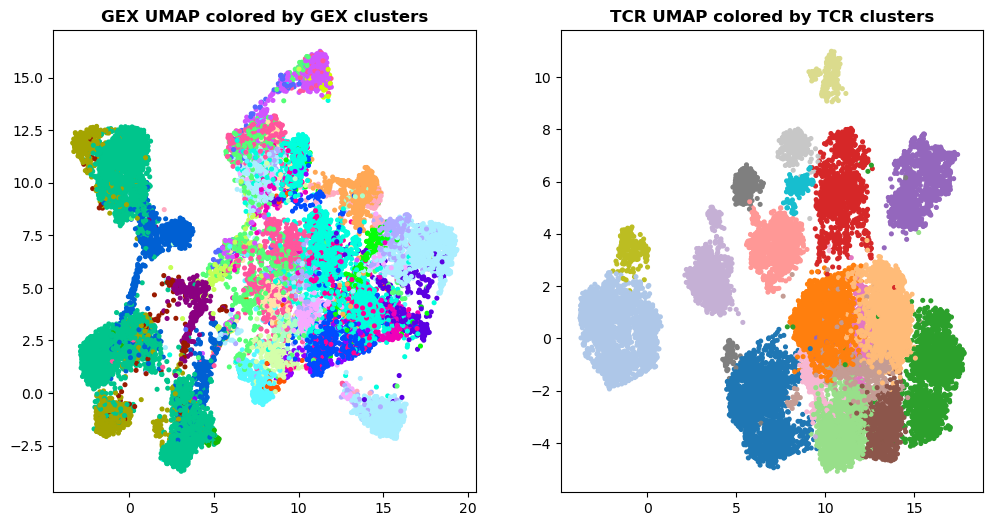

In [106]:
plt.figure(figsize=(12,6))
plt.subplot(121)
xy = adata_ab.obsm['X_gex_2d']
clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values
cmap = plt.get_cmap('tab20')
# colors = adata_ab.obs['celltype_colorcode']
colors = [cmap_30.colors[34-x] for x in clusters_gex_num]
GEX_color_array = colors

plt.scatter( xy[:,0], xy[:,1], c=colors,s =7)
# plt.legend()
plt.title('GEX UMAP colored by GEX clusters',fontweight = 'bold')

plt.subplot(122)
xy = adata_ab.obsm['X_tcr_2d']
clusters = np.array(adata_ab.obs['clusters_tcr'])
cmap = plt.get_cmap('tab20')
colors = [ cmap.colors[x%20] for x in clusters]
plt.scatter( xy[:,0], xy[:,1], c=colors,s =7)
plt.title('TCR UMAP colored by TCR clusters',fontweight = 'bold')

In [107]:
color_df = pd.DataFrame(adata_ab.obs['tissue+celltype'])
color_df['clusters_gex_num'] = clusters_gex_num
color_df['tissue_celltype_colors'] = GEX_color_array
color_df['cluster_legend'] = color_df['clusters_gex_num'].astype(str).map(str) + ': ' + color_df['tissue+celltype'].astype(str).map(str)    
color_df = color_df.drop_duplicates(subset = 'cluster_legend')
color_df = color_df.set_index('cluster_legend')
color_dict_30 = color_df['tissue_celltype_colors'].sort_index().to_dict()
color_dict_30

{'0: IEL TCRab CD4 FOXP3+ Treg': array([1.        , 0.66666667, 0.75196084, 1.        ]),
 '10: L TCRab CD8ab Naive/TCM': array([0.33333333, 0.9772078 , 1.        , 1.        ]),
 '11: L TCRab CD8ab TRM': array([0.33333333, 1.        , 0.46691265, 1.        ]),
 '12: L TCRab CD8ab Teff': array([0.77107754, 1.        , 0.33333333, 1.        ]),
 '13: LP TCRab CD4 FOXP3+ Treg': array([1.        , 0.65759836, 0.33333333, 1.        ]),
 '14: LP TCRab CD4 Mobile TRM': array([1.        , 0.        , 0.58014755, 1.        ]),
 '15: LP TCRab CD4 Naive/TCM': array([0.5628663, 0.       , 1.       , 1.       ]),
 '16: LP TCRab CD4 Poised TCM': array([0.        , 0.29411985, 1.        , 1.        ]),
 '17: LP TCRab CD4 TRM': array([0.       , 1.       , 0.8720566, 1.       ]),
 '18: LP TCRab CD4 Tph': array([0.01580815, 1.        , 0.0308837 , 1.        ]),
 '19: LP TCRab CD8aa MAIT': array([0.81874882, 1.        , 0.        , 1.        ]),
 '1: IEL TCRab CD4 Mobile TRM': array([0.97009771, 0.6666

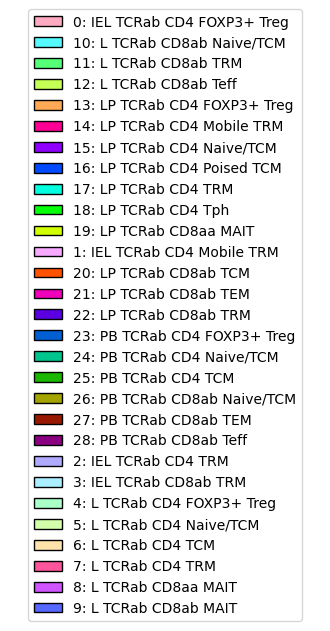

In [108]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=celltype)
    for celltype, color in color_dict_30.items()
]

# Create figure and add legend
plt.figure(figsize=(4, 2))
plt.legend(handles=legend_elements, loc='center', frameon=True)
plt.axis('off')  # Hide axes
# plt.title("Cell Type Color Legend")
plt.show()

Text(0.5, 1.0, 'GEX UMAP colored by TCR clusters')

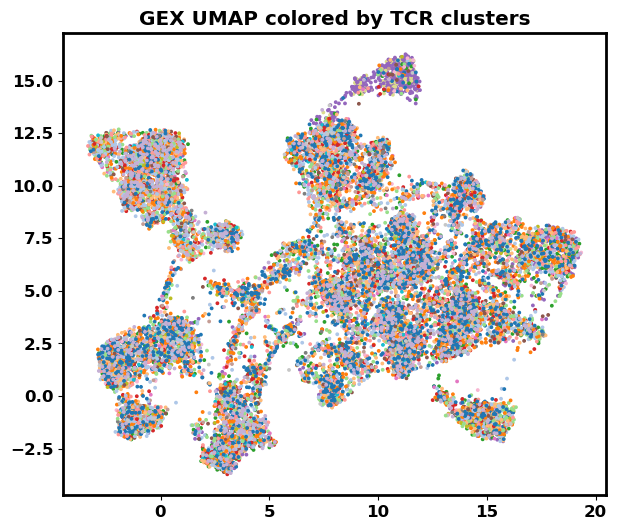

In [118]:
plt.figure(figsize=(7,6))
xy = adata_ab.obsm['X_gex_2d']
clusters = np.array(adata_ab.obs['clusters_tcr'])
cmap = plt.get_cmap('tab20')
colors = [ cmap.colors[x%20] for x in clusters]
plt.scatter( xy[:,0], xy[:,1], c=colors,s=3)
plt.title('GEX UMAP colored by TCR clusters',fontweight = 'bold')

In [98]:
adata_ab.write('250721_gut_liver_TRM_adata_abTCR_conga.h5ad')
# adata_ab = sc.read_h5ad('250721_gut_liver_TRM_adata_abTCR_conga.h5ad')

In [ ]:
# these are the nbrhood sizes, as a fraction of the entire dataset:
nbr_fracs = [0.01, 0.1]

# we use this nbrhood size for computing the nndists
nbr_frac_for_nndists = 0.01

all_nbrs, nndists_gex, nndists_tcr = conga.preprocess.calc_nbrs(
    adata_ab, nbr_fracs, also_calc_nndists=True, nbr_frac_for_nndists=nbr_frac_for_nndists)

# stash these in obs array, they are used in a few places...
adata_ab.obs['nndists_gex'] = nndists_gex
adata_ab.obs['nndists_tcr'] = nndists_tcr
# adata_ab.uns['all_nbrs'] = all_nbrs
conga.preprocess.setup_tcr_cluster_names(adata_ab) #stores in adata_ab.uns

allocating memory for 3535528 gex nbrs
allocated 14142112 bytes memory id= 2366884986000
allocating memory for 3535528 tcr nbrs
allocated 14142112 bytes memory id= 2366849082704
allocating memory for 35355280 gex nbrs
allocated 141421120 bytes memory id= 2366883898320
allocating memory for 35355280 tcr nbrs
allocated 141421120 bytes memory id= 2366893824912
compute D gex batch= 0 num_batches= 6 N= 18806 batch_size= 3568
argpartitions: gex batch= 0 nbr_frac= 0.01
argpartitions: gex batch= 0 nbr_frac= 0.1
compute D tcr batch= 0 num_batches= 6 N= 18806 batch_size= 3568
argpartitions: tcr batch= 0 nbr_frac= 0.01
argpartitions: tcr batch= 0 nbr_frac= 0.1
compute D gex batch= 1 num_batches= 6 N= 18806 batch_size= 3568
argpartitions: gex batch= 1 nbr_frac= 0.01
argpartitions: gex batch= 1 nbr_frac= 0.1
compute D tcr batch= 1 num_batches= 6 N= 18806 batch_size= 3568
argpartitions: tcr batch= 1 nbr_frac= 0.01
argpartitions: tcr batch= 1 nbr_frac= 0.1
compute D gex batch= 2 num_batches= 6 N= 188

In [ ]:
import joblib
# joblib.dump(all_nbrs, 'all_nbrs.pkl')
all_nbrs = joblib.load('all_nbrs.pkl')

['all_nbrs.pkl']

In [94]:
adata_ab.write('C:/Users/andre/250721_gut_liver_TRM_adata_abTCR_conga.h5ad')
# adata_ab = sc.read_h5ad('250721_gut_liver_TRM_adata_abTCR_conga.h5ad')

In [99]:
results = conga.correlations.run_graph_vs_graph(
    adata_ab, all_nbrs, outfile_prefix='C:/Users/andre/'+outfile_prefix)

results.head()

find_neighbor_neighbor_interactions:


c:\users\andre\conga\conga\correlations.py:111: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[double_nbrs])/overlap,


find_neighbor_cluster_interactions:


c:\users\andre\conga\conga\correlations.py:189: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[same_cluster_nbrs])/overlap


find_neighbor_cluster_interactions:


...

find_neighbor_cluster_interactions:


c:\users\andre\conga\conga\correlations.py:189: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[same_cluster_nbrs])/overlap


saved graph_vs_graph results to tsvfile: C:/Users/andre/conga_output_gut_liver_TRM_graph_vs_graph.tsv


c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\a

,conga_score,num_neighbors_gex,num_neighbors_tcr,overlap,overlap_corrected,mait_fraction,clone_index,nbr_frac,graph_overlap_type,cluster_size,gex_cluster,tcr_cluster,va,ja,cdr3a,vb,jb,cdr3b
5394,2.714989e-80,NaN,1880.0,211,210,0.0,14944,0.1,gex_cluster_vs_tcr_nbr,484.0,LP TCRab CD4 Mobile TRM,6,TRAV39*01,TRAJ58*01,CAVGETSGSRLTF,TRBV20-1*01,TRBJ1-5*01,CSARDVGSPSQPQHF
4884,4.730180e-72,NaN,1880.0,202,200,0.0,8637,0.1,gex_cluster_vs_tcr_nbr,483.0,LP TCRab CD4 Mobile TRM,6,TRAV22*01,TRAJ15*01,CAPGRTQAGTALIF,TRBV20-1*01,TRBJ2-1*01,CSARIPGRLRDEQFF
5452,1.670472e-68,NaN,1880.0,198,196,0.0,15920,0.1,gex_cluster_vs_tcr_nbr,484.0,LP TCRab CD4 Mobile TRM,6,TRAV6*01,TRAJ15*01,CALGTQAGTALIF,TRBV20-1*01,TRBJ2-7*01,CSARGGSAYEQYF
4757,2.804252e-68,NaN,1880.0,197,196,0.0,6697,0.1,gex_cluster_vs_tcr_nbr,484.0,LP TCRab CD4 Mobile TRM,16,TRAV19*01,TRAJ27*01,CALSEAGAGKSTF,TRBV20-1*01,TRBJ1-5*01,CSARDGAENQPQHF
4832,5.026791e-66,NaN,1880.0,195,193,0.0,7686,0.1,gex_cluster_vs_tcr_nbr,484.0,LP TCRab CD4 Mobile TRM,6,TRAV20*01,TRAJ32*01,CAPRAGATNKLIF,TRBV20-1*01,TRBJ1-5*01,CSAKQGGEHQPQHF


C:\Users\andre\AppData\Local\Temp\ipykernel_28572\501399136.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))
C:\Users\andre\AppData\Local\Temp\ipykernel_28572\501399136.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))


(np.float64(-4.858666110038757),
 np.float64(18.8855792760849),
 np.float64(-5.887813949584961),
 np.float64(11.795261764526368))

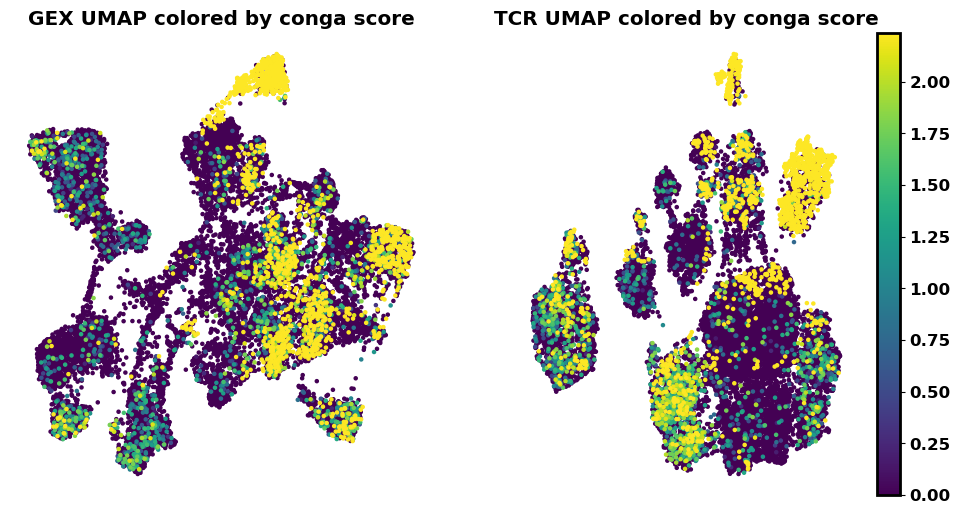

In [119]:
#put the conga hits on top
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold','axes.linewidth':2})
conga_scores = adata_ab.obs['conga_scores']
colors = np.sqrt(np.maximum(-1*np.log10(conga_scores),0.0))
reorder = np.argsort(colors)

plt.figure(figsize=(12,6))
plt.subplot(121)
xy = adata_ab.obsm['X_gex_2d']
plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))
plt.title('GEX UMAP colored by conga score',fontweight = 'bold')
plt.axis('off')

plt.subplot(122)
xy = adata_ab.obsm['X_tcr_2d']
plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))
plt.colorbar()
plt.title('TCR UMAP colored by conga score',fontweight = 'bold')
plt.axis('off')

In [83]:
adata_ab.obs['clusters_gex'] = clusters_gex_num

making tcr score table, #features= 35


c:\users\andre\conga\conga\correlations.py:977: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction = np.sum(nbrhood_is_mait[ top_indices ] )\


run rank_genes_groups [('none', 16313), ('clp_8_8', 288), ('clp_17_0', 219), ('clp_3_8', 199), ('clp_24_4', 117), ('clp_16_0', 115), ('clp_8_17', 111), ('clp_26_1', 105), ('clp_3_1', 83), ('clp_24_1', 80), ('clp_24_6', 67), ('clp_13_0', 67), ('clp_7_0', 51), ('clp_3_4', 46), ('clp_11_0', 46), ('clp_23_1', 43), ('clp_26_4', 42), ('clp_3_5', 42), ('clp_11_8', 39), ('clp_9_8', 39), ('clp_24_7', 39), ('clp_24_9', 37), ('clp_6_0', 32), ('clp_7_8', 31), ('clp_3_0', 29), ('clp_14_0', 27), ('clp_3_2', 26), ('clp_14_6', 22), ('clp_5_0', 21), ('clp_1_9', 21), ('clp_2_0', 20), ('clp_1_0', 19), ('clp_18_0', 19), ('clp_22_8', 16), ('clp_15_0', 16), ('clp_24_16', 15), ('clp_3_17', 14), ('clp_19_8', 14), ('clp_23_5', 14), ('clp_3_7', 14), ('clp_3_3', 13), ('clp_16_9', 13), ('clp_24_14', 12), ('clp_22_1', 11), ('clp_17_14', 10), ('clp_3_10', 9), ('clp_4_0', 9), ('clp_24_3', 9), ('clp_2_8', 8), ('clp_17_6', 8), ('clp_27_1', 8), ('clp_10_0', 8), ('clp_23_6', 7), ('clp_17_4', 7), ('clp_3_14', 7), ('clp_1

c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanp

making cluster logos: 0 73 conga_output_gut_liver_TRM_graph_vs_graph_logos.png


c:\users\andre\conga\conga\plotting.py:1179: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_cells = sum( clone_sizes[x] for x in nodes )


AssertionError: 

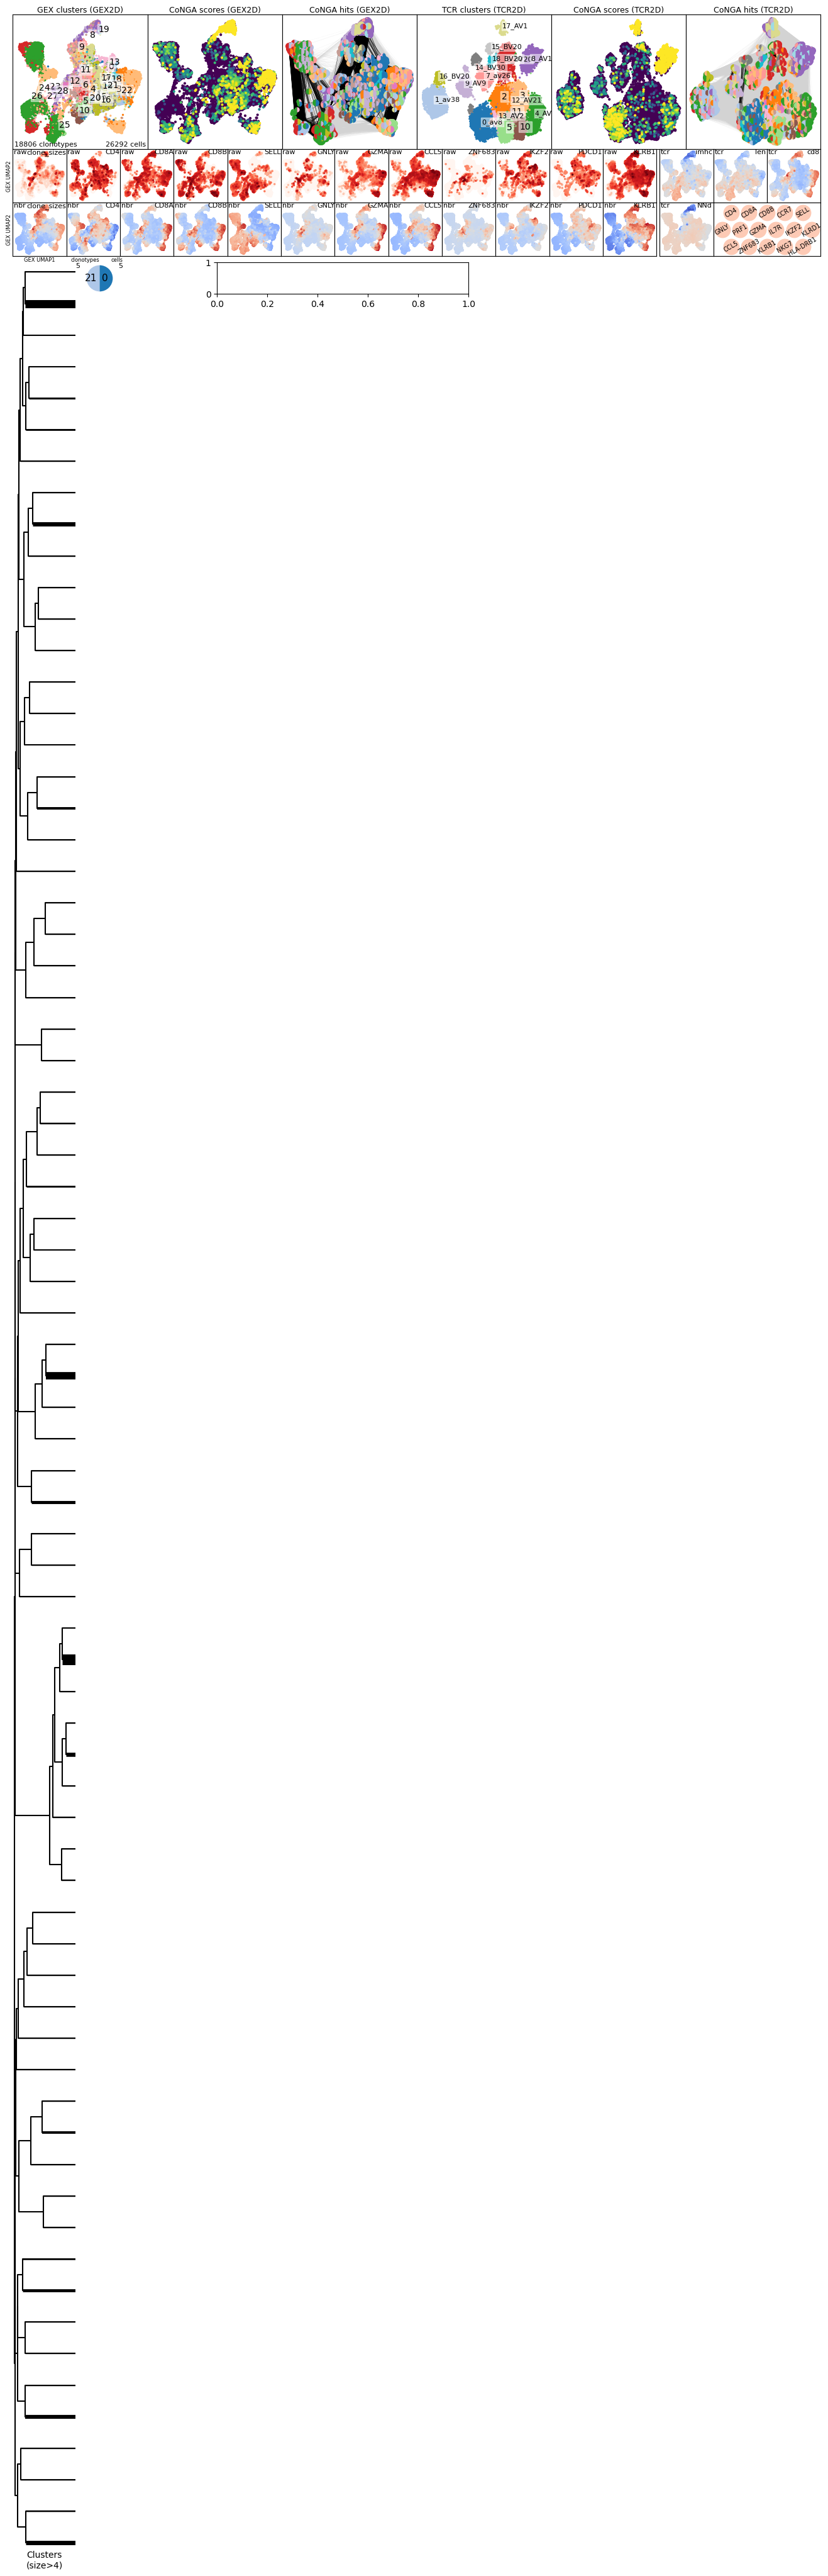

In [109]:
nbrs_gex, nbrs_tcr = all_nbrs[0.1]

min_cluster_size = 5
conga.plotting.make_graph_vs_graph_logos(
    adata_ab,
    outfile_prefix,
    min_cluster_size,
    nbrs_gex,
    nbrs_tcr,
)